In [ ]:
# Paths below are relative to the repository root: run from there even though this file is in notebooks/
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")


# Wake Word Data Generation Pipeline

End-to-end synthetic corpus generation for a **"Hey Delta"** wake-word detector:
synthetic positives plus synthetic hard negatives, partial/truncated wakeword
negatives, continuous-speech negatives, synthetic media/background negatives,
silence/ambient negatives, and augmentation assets (RIR/noise).

Actual recordings are intentionally **not synthesized here**. The manifest schema
includes `speaker_id` / `recording_id` / `source_id` fields so manually uploaded
real recordings can be added later without changing the downstream split logic.

**Phases**
1. Setup & Config
2. Positive Clip Generation & ASR Verification
3. Synthetic Negative Generation
   - phonetically similar / near-miss phrases
   - partial/truncated wakeword utterances
   - continuous general speech
   - synthetic TV/podcast/music/background mixtures
   - silence / low-level non-speech
4. RIR & Noise Collection
5. Manifest Consolidation, Stats & Export
6. Synthetic Streaming-Style False-Accept Evaluation Set

> Run top-to-bottom. External HF/RIR downloads remain optional augmentation sources;
> the required negative *classes* are generated synthetically so the pipeline does
> not depend on real recordings. Manually uploaded recordings can be added later.


## Phase 1 — Environment Setup & Config

In [1]:
# 1. Environment setup
# ---------------------------------------------------------------------------
%pip install -q piper-tts edge-tts faster-whisper datasets librosa soundfile \
    pydub pandas tqdm jiwer phonemizer g2p_en nltk matplotlib ipywidgets requests
print("Environment setup complete.")


Note: you may need to restart the kernel to use updated packages.
Environment setup complete.


In [2]:
# 2. Config block
# ---------------------------------------------------------------------------
import os
import random
import json
from pathlib import Path
from datetime import datetime, timezone

CONFIG = {
    "wake_word": "Hey Delta",
    "sample_rate": 48000,
    "random_seed": 42,

    # Safe reruns: remove only generator-owned synthetic filenames before regeneration.
    "clean_synthetic_outputs_before_run": True,

    # Fixed downstream clip framing.
    "clip_len_sec": 1.5,

    # Synthetic corpus targets. These are intentionally asymmetric: hard-negative
    # linguistic content gets dedicated capacity rather than merely multiplying
    # simple noise clips.
    "target_counts": {
        "positives": 2000,
        "negatives_general": 1800,       # synthetic continuous speech
        "negatives_confusable": 1200,    # phonetic / lexical near-misses
        "negatives_partial": 800,        # truncated / incomplete wakeword
        "negatives_media": 1000,         # synthetic TV/podcast/music/background
        "negatives_silence": 1000,       # silence / low-level non-speech
        "streaming_eval": 120,           # separate long-form synthetic streams
        "rir": 300,
        "noise": 500,
    },

    "output_root": "data",
    "dirs": {
        "positives": "data/positives",
        "negatives_general": "data/negatives_general",
        "negatives_confusable": "data/negatives_confusable",
        "negatives_partial": "data/negatives_partial",
        "negatives_media": "data/negatives_media",
        "negatives_silence": "data/negatives_silence",
        "streaming_eval": "data/streaming_eval",
        "rir": "data/rir",
        "noise": "data/noise",
        "logs": "data/logs",
    },

    "manifest_path": "data/manifest.csv",
    "manifest_columns": [
        "filepath", "label", "category", "source", "source_id",
        "speaker_id", "recording_id",
        "duration_sec", "sample_rate", "voice", "speed", "pitch",
        "transcription", "edit_distance", "parent_filepath", "created_at",
    ],

    # ASR verification
    "whisper_model_size": "small",
    "asr_match_max_edit_distance_ratio": 0.25,

    # Positive TTS variation grid.
    "speed_variations": [0.85, 1.0, 1.15],
    "pitch_variations": [-2, 0, 2],

    "edge_tts_voices": ["fil-PH-AngeloNeural", "fil-PH-BlessicaNeural"],
    "piper_voices": [
        "en_US-lessac-medium", "en_US-amy-medium", "en_US-ryan-medium",
        "en_GB-alan-medium", "en_GB-alba-medium",
        "vi_VN-vivos-x_low", "id_ID-news_tts-medium",
    ],

    # Synthetic speech generation controls.
    "synthetic_speech": {
        "general_recordings": 220,       # each recording is one source group
        "general_sentences_per_recording": (5, 9),
        "general_recording_duration_sec": (6.0, 12.0),
        "confusable_speed": (0.92, 1.08),
        "confusable_pitch": (-1.5, 1.5),
        "partial_min_fraction": 0.30,
        "partial_max_fraction": 0.82,
        "media_recordings": 180,
        "stream_count": 120,
        "stream_duration_sec": 30.0,
    },
}

random.seed(CONFIG["random_seed"])
print(json.dumps(CONFIG, indent=2))


{
  "wake_word": "Hey Delta",
  "sample_rate": 48000,
  "random_seed": 42,
  "target_counts": {
    "positives": 2000,
    "negatives_general": 4000,
    "negatives_confusable": 1500,
    "negatives_silence": 1000,
    "rir": 300,
    "noise": 500
  },
  "output_root": "data",
  "dirs": {
    "positives": "data/positives",
    "negatives_general": "data/negatives_general",
    "negatives_confusable": "data/negatives_confusable",
    "negatives_silence": "data/negatives_silence",
    "rir": "data/rir",
    "noise": "data/noise",
    "logs": "data/logs"
  },
  "manifest_path": "data/manifest.csv",
  "manifest_columns": [
    "filepath",
    "label",
    "category",
    "source",
    "duration_sec",
    "sample_rate",
    "voice",
    "speed",
    "pitch",
    "transcription",
    "edit_distance",
    "created_at"
  ],
  "whisper_model_size": "small",
  "asr_match_max_edit_distance_ratio": 0.25,
  "speed_variations": [
    0.85,
    1.0,
    1.15
  ],
  "pitch_variations": [
    -2,
    0

In [3]:
# 3. Directory scaffolding
# ---------------------------------------------------------------------------
for key, d in CONFIG["dirs"].items():
    Path(d).mkdir(parents=True, exist_ok=True)
    print(f"ok  {key:22s} -> {d}")

manifest_path = Path(CONFIG["manifest_path"])
if not manifest_path.exists():
    with open(manifest_path, "w") as f:
        f.write(",".join(CONFIG["manifest_columns"]) + "\n")
    print(f"created manifest stub -> {manifest_path}")
else:
    print(f"manifest already exists -> {manifest_path}")


print("Existing data is preserved; safe synthetic cleanup runs in the next cell.")


ok  positives              -> data/positives
ok  negatives_general      -> data/negatives_general
ok  negatives_confusable   -> data/negatives_confusable
ok  negatives_silence      -> data/negatives_silence
ok  rir                    -> data/rir
ok  noise                  -> data/noise
ok  logs                   -> data/logs
created manifest stub -> data/manifest.csv


In [ ]:

# 3b. Safe synthetic-output cleanup (idempotent reruns)
# ---------------------------------------------------------------------------
# This cell removes ONLY files whose names are reserved for this notebook's
# synthetic generator. It deliberately does NOT delete arbitrary/manual files.
# Therefore you can rerun the notebook after adding real recordings manually.
#
# Safe to rerun: generated files are regenerated with the same reserved names;
# stale generated files from an older configuration are removed first.

import re

SAFE_SYNTHETIC_PATTERNS = {
    "positives": [re.compile(r"^.+_spd(?:0\.85|1\.0|1\.15)_pit(?:-2|0|2)\.wav$")],
    "negatives_general": [re.compile(r"^speech_.*_\d{3}\.wav$")],
    "negatives_confusable": [re.compile(r"^conf_\d{5}\.wav$")],
    "negatives_partial": [re.compile(r"^partial_\d{5}\.wav$")],
    "negatives_media": [re.compile(r"^media_.*_\d{3}\.wav$")],
    "negatives_silence": [re.compile(r"^synth_(?:white|pink|hum|fan|clicks)_\d{5}\.wav$")],
    "streaming_eval": [re.compile(r"^syn_stream_\d{4}\.wav$")],
    "rir": [re.compile(r"^rir_\d{5}\.wav$")],
    "noise": [re.compile(r"^noise_\d{5}\.wav$")],
}

# Generated raw source files. These live in _raw/_raw_sources and are safe to
# remove only when their names are explicitly generator-owned.
SAFE_RAW_PATTERNS = {
    Path(CONFIG["dirs"]["negatives_general"]) / "_raw_sources": [
        re.compile(r"^syn_general_rec_\d{4}.*\.wav$")
    ],
    Path(CONFIG["dirs"]["negatives_media"]) / "_raw_sources": [
        re.compile(r"^syn_media_rec_\d{4}.*\.wav$")
    ],
    Path(CONFIG["dirs"]["negatives_silence"]) / "_raw": [
        re.compile(r"^synth_(?:white|pink|hum|fan|clicks)_\d{5}\.wav$")
    ],
}

if not CONFIG.get("clean_synthetic_outputs_before_run", True):
    print("Synthetic cleanup disabled by configuration; no files will be removed.")
    SAFE_SYNTHETIC_PATTERNS = {}
    SAFE_RAW_PATTERNS = {}

def _safe_clean_dir(dir_key, patterns):
    root = Path(CONFIG["dirs"][dir_key])
    removed = 0
    if not root.exists():
        return 0
    for p in root.iterdir():
        if p.is_file() and any(rx.fullmatch(p.name) for rx in patterns):
            p.unlink()
            removed += 1
    return removed

removed_total = 0
for key, patterns in SAFE_SYNTHETIC_PATTERNS.items():
    n = _safe_clean_dir(key, patterns)
    if n:
        print(f"[cleanup] {key}: removed {n} prior synthetic files")
    removed_total += n

for root, patterns in SAFE_RAW_PATTERNS.items():
    root = Path(root)
    if not root.exists():
        continue
    n = 0
    for p in root.iterdir():
        if p.is_file() and any(rx.fullmatch(p.name) for rx in patterns):
            p.unlink()
            n += 1
    if n:
        print(f"[cleanup] {root}: removed {n} prior synthetic raw files")
    removed_total += n

print(f"Safe synthetic cleanup complete: {removed_total} files removed.")
print("Manual/unrecognized files were NOT deleted.")


In [4]:
import asyncio

available_edge_voices = []

async def _check_edge_voices():
    try:
        import edge_tts
        all_voices = await edge_tts.list_voices()
        available_short_names = {v["ShortName"] for v in all_voices}
        for voice in CONFIG["edge_tts_voices"]:
            ok = voice in available_short_names
            available_edge_voices.append(voice) if ok else None
            print(f"[edge-tts] {voice:28s} {'AVAILABLE' if ok else 'NOT FOUND'}")
    except Exception as e:
        print(f"[edge-tts] voice check failed (non-fatal): {e}")

try:
    asyncio.run(_check_edge_voices())
except RuntimeError:
    # already inside an event loop (e.g. Jupyter kernels)
    import nest_asyncio
    nest_asyncio.apply()
    asyncio.run(_check_edge_voices())

print(f"\nedge-tts voices available: {available_edge_voices}")

[edge-tts] fil-PH-AngeloNeural          AVAILABLE
[edge-tts] fil-PH-BlessicaNeural        AVAILABLE

edge-tts voices available: ['fil-PH-AngeloNeural', 'fil-PH-BlessicaNeural']


/tmp/ipykernel_1259818/2227869923.py:23: RuntimeWarning: coroutine '_check_edge_voices' was never awaited
  asyncio.run(_check_edge_voices())


In [5]:
# 4b. Download piper voices
# ---------------------------------------------------------------------------
# Uses the `piper` CLI's voice downloader if available, else falls back to
# huggingface_hub (piper voices are mirrored on the rhasspy/piper-voices repo).
piper_download_status = {}

def download_piper_voice(voice_name: str) -> bool:
    try:
        from huggingface_hub import hf_hub_download
        # rhasspy/piper-voices layout: <lang>/<lang_region>/<name>/<quality>/<file>
        lang_root = voice_name.split("-")[0]           # e.g. en_US
        lang_short = lang_root.split("_")[0]            # e.g. en
        name, quality = voice_name.split("-")[1], voice_name.split("-")[2]
        base = f"{lang_short}/{lang_root}/{name}/{quality}"
        onnx_file = f"{base}/{voice_name}.onnx"
        json_file = f"{base}/{voice_name}.onnx.json"
        dest_dir = Path("voices/piper") / voice_name
        dest_dir.mkdir(parents=True, exist_ok=True)
        for fname in (onnx_file, json_file):
            hf_hub_download(
                repo_id="rhasspy/piper-voices",
                filename=fname,
                local_dir="voices/piper_raw",
            )
        return True
    except Exception as e:
        print(f"    reason: {e}")
        return False

for voice in CONFIG["piper_voices"]:
    ok = download_piper_voice(voice)
    piper_download_status[voice] = ok
    print(f"[piper] {voice:28s} {'DOWNLOADED' if ok else 'FAILED (skipped, non-fatal)'}")

print("\nPiper download summary:")
for v, ok in piper_download_status.items():
    print(f"  {'OK ' if ok else 'FAIL'}  {v}")


en/en_US/lessac/medium/en_US-lessac-medi(…): reconstructing file:   0%|          |  0.00B / 63.2MB            

en/en_US/lessac/medium/en_US-lessac-medi(…): downloading bytes:           |  0.00B            

en_US-lessac-medium.onnx.json:   0%|          | 0.00/4.88k [00:00<?, ?B/s]

[piper] en_US-lessac-medium          DOWNLOADED


en/en_US/amy/medium/en_US-amy-medium.onn(…): reconstructing file:   0%|          |  0.00B / 63.2MB            

...

[piper] vi_VN-vivos-x_low            DOWNLOADED


id/id_ID/news_tts/medium/id_ID-news_tts-(…): reconstructing file:   0%|          |  0.00B / 63.0MB            

id/id_ID/news_tts/medium/id_ID-news_tts-(…): downloading bytes:           |  0.00B            

id_ID-news_tts-medium.onnx.json:   0%|          | 0.00/5.05k [00:00<?, ?B/s]

[piper] id_ID-news_tts-medium        DOWNLOADED

Piper download summary:
  OK   en_US-lessac-medium
  OK   en_US-amy-medium
  OK   en_US-ryan-medium
  OK   en_GB-alan-medium
  OK   en_GB-alba-medium
  OK   vi_VN-vivos-x_low
  OK   id_ID-news_tts-medium


## Phase 2 — Positive Clip Generation & ASR Verification

In [ ]:
import nest_asyncio
nest_asyncio.apply()

In [6]:
# 5. Generate positive clips: voices x speed x pitch
# ---------------------------------------------------------------------------
import subprocess
import itertools
import wave

positives_dir = Path(CONFIG["dirs"]["positives"])
usable_piper_voices = [v for v, ok in piper_download_status.items() if ok]
usable_edge_voices = available_edge_voices

generated_positive_rows = []

def synth_piper(text, voice, speed, pitch, out_path):
    """Synthesize with a local piper voice, applying speed via piper's
    length_scale (inverse of speed) and a pitch shift as a post-process."""
    model_path = Path("voices/piper_raw") / voice.split("-")[0] / "_".join(voice.split("-")[:2])
    onnx_files = list(Path("voices/piper_raw").rglob(f"{voice}.onnx"))
    if not onnx_files:
        raise FileNotFoundError(f"piper model not found for {voice}")
    onnx_path = onnx_files[0]
    length_scale = 1.0 / speed
    cmd = [
        "piper", "--model", str(onnx_path),
        "--length_scale", str(length_scale),
        "--output_file", str(out_path),
    ]
    subprocess.run(cmd, input=text.encode(), check=True, capture_output=True)
    if pitch != 0:
        _apply_pitch_shift(out_path, pitch)

async def synth_edge(text, voice, speed, pitch, out_path):
    import edge_tts
    rate_pct = int((speed - 1.0) * 100)
    pitch_hz = pitch * 50  # rough semitone -> Hz offset for edge-tts pitch param
    rate_str = f"{'+' if rate_pct >= 0 else ''}{rate_pct}%"
    pitch_str = f"{'+' if pitch_hz >= 0 else ''}{pitch_hz}Hz"
    communicate = edge_tts.Communicate(text, voice, rate=rate_str, pitch=pitch_str)
    await communicate.save(str(out_path))

def _apply_pitch_shift(path, semitones):
    try:
        import librosa, soundfile as sf
        y, sr = librosa.load(path, sr=None)
        y_shifted = librosa.effects.pitch_shift(y, sr=sr, n_steps=semitones)
        sf.write(path, y_shifted, sr)
    except Exception as e:
        print(f"    pitch shift skipped for {path.name}: {e}")

combos = list(itertools.product(
    usable_piper_voices + usable_edge_voices,
    CONFIG["speed_variations"],
    CONFIG["pitch_variations"],
))
print(f"Planned {len(combos)} voice x speed x pitch combinations "
      f"({len(usable_piper_voices)} piper + {len(usable_edge_voices)} edge voices).")

n_ok, n_fail = 0, 0
for voice, speed, pitch in combos:
    safe_voice = voice.replace("/", "_")
    fname = f"{safe_voice}_spd{speed}_pit{pitch}.wav"
    out_path = positives_dir / fname
    try:
        if voice in usable_piper_voices:
            synth_piper(CONFIG["wake_word"], voice, speed, pitch, out_path)
        else:
            asyncio.run(synth_edge(CONFIG["wake_word"], voice, speed, pitch, out_path))
        generated_positive_rows.append({
            "filepath": str(out_path), "voice": voice, "speed": speed, "pitch": pitch,
        })
        n_ok += 1
    except Exception as e:
        n_fail += 1
        # non-fatal: keep going through the grid
        continue

print(f"\nGenerated {n_ok} positive clips, {n_fail} failures (skipped).")


Planned 81 voice x speed x pitch combinations (7 piper + 2 edge voices).


Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/arvir.jane.redondo/.conda/envs/conda_arvir/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x745ed6793a00> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-13' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/arvir.jane.redondo/.conda/envs/conda_arvir/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-14' coro=<Kernel.shell_main() running at /home/arvir.jane.redondo/.conda/envs/conda_arvir/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/arvir.jane.redondo/.conda/envs/conda_arvir/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:564]>
/home/arvir.jane.redondo/.


Generated 81 positive clips, 0 failures (skipped).


In [7]:
import os
print(os.environ.get("HTTP_PROXY"), os.environ.get("HTTPS_PROXY"), os.environ.get("NO_PROXY"))

None None None


In [10]:
# 6. Batch transcribe positives with faster-whisper (single most-free GPU)
# ---------------------------------------------------------------------------
def pick_best_gpu():
    """Return the index of the GPU with the most free memory, or None if no
    GPU is visible. Never selects more than one device."""
    try:
        import subprocess
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=index,memory.free", "--format=csv,noheader,nounits"]
        ).decode()
        rows = [line.split(",") for line in out.strip().splitlines()]
        rows = [(int(idx), int(free_mb)) for idx, free_mb in rows]
        if not rows:
            return None
        best_idx, best_free = max(rows, key=lambda r: r[1])
        print(f"Selected GPU {best_idx} with {best_free} MiB free "
              f"(candidates: {rows}).")
        return best_idx
    except Exception as e:
        print(f"No GPU detected / nvidia-smi unavailable, falling back to CPU: {e}")
        return None

gpu_index = pick_best_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = "" if gpu_index is None else str(gpu_index)

from faster_whisper import WhisperModel

device = "cuda" if gpu_index is not None else "cpu"
compute_type = "float16" if device == "cuda" else "int8"

whisper_model = WhisperModel(
    CONFIG["whisper_model_size"],
    device=device,
    device_index=0,          # index 0 within CUDA_VISIBLE_DEVICES, i.e. our chosen GPU
    compute_type=compute_type,
)
print(f"faster-whisper loaded on device={device}, compute_type={compute_type}")

transcriptions = {}
for row in generated_positive_rows:
    fp = row["filepath"]
    try:
        segments, _info = whisper_model.transcribe(fp, language="en", beam_size=5)
        text = " ".join(seg.text.strip() for seg in segments).strip()
        transcriptions[fp] = text
    except Exception as e:
        transcriptions[fp] = ""
        print(f"transcription failed for {fp}: {e}")

print(f"\nTranscribed {len(transcriptions)} clips.")
for fp, text in list(transcriptions.items())[:5]:
    print(f"  {Path(fp).name:45s} -> {text!r}")


Selected GPU 7 with 40438 MiB free (candidates: [(0, 38804), (1, 33356), (2, 40005), (3, 38864), (4, 38864), (5, 39008), (6, 2202), (7, 40438)]).
faster-whisper loaded on device=cuda, compute_type=float16

Transcribed 81 clips.
  en_US-lessac-medium_spd0.85_pit-2.wav         -> "He's also"
  en_US-lessac-medium_spd0.85_pit0.wav          -> 'Hey Delta!'
  en_US-lessac-medium_spd0.85_pit2.wav          -> 'Hey Delta!'
  en_US-lessac-medium_spd1.0_pit-2.wav          -> 'Hey Delta!'
  en_US-lessac-medium_spd1.0_pit0.wav           -> 'Hey Delta!'


In [11]:
# 7. Fuzzy-match transcription vs. target phrase; discard mismatches
# ---------------------------------------------------------------------------
def normalized_edit_distance(a: str, b: str) -> float:
    a, b = a.lower().strip(), b.lower().strip()
    if not a and not b:
        return 0.0
    # simple Levenshtein
    dp = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        prev = dp[0]
        dp[0] = i
        for j, cb in enumerate(b, 1):
            cur = dp[j]
            dp[j] = min(dp[j] + 1, dp[j - 1] + 1, prev + (ca != cb))
            prev = cur
    return dp[-1] / max(len(a), len(b), 1)

kept_rows, discarded_rows = [], []
for row in generated_positive_rows:
    fp = row["filepath"]
    text = transcriptions.get(fp, "")
    dist_ratio = normalized_edit_distance(text, CONFIG["wake_word"])
    row["transcription"] = text
    row["edit_distance"] = round(dist_ratio, 4)
    if dist_ratio <= CONFIG["asr_match_max_edit_distance_ratio"]:
        kept_rows.append(row)
    else:
        discarded_rows.append(row)

print(f"Pass: {len(kept_rows)}   Fail (discarded): {len(discarded_rows)}   "
      f"Threshold: {CONFIG['asr_match_max_edit_distance_ratio']}")

# remove failing files from disk to keep positives/ clean (comment out to keep for inspection)
for row in discarded_rows:
    try:
        Path(row["filepath"]).unlink(missing_ok=True)
    except Exception:
        pass


Pass: 50   Fail (discarded): 31   Threshold: 0.25


In [12]:
# 8. Quick stats: kept counts, breakdown by voice, duration distribution
# ---------------------------------------------------------------------------
import pandas as pd
import soundfile as sf

pos_df = pd.DataFrame(kept_rows)

def get_duration(fp):
    try:
        info = sf.info(fp)
        return info.frames / info.samplerate
    except Exception:
        return float("nan")

if not pos_df.empty:
    pos_df["duration_sec"] = pos_df["filepath"].apply(get_duration)
    print(f"Total kept positives: {len(pos_df)}")
    print("\nBreakdown by voice:")
    print(pos_df.groupby("voice").size().sort_values(ascending=False))
    print("\nDuration stats (sec):")
    print(pos_df["duration_sec"].describe())
    outliers = pos_df[
        (pos_df["duration_sec"] < pos_df["duration_sec"].quantile(0.02)) |
        (pos_df["duration_sec"] > pos_df["duration_sec"].quantile(0.98))
    ]
    print(f"\nPotential duration outliers: {len(outliers)}")
else:
    print("No positives kept — check TTS/ASR steps above before continuing.")


Total kept positives: 50

Breakdown by voice:
voice
en_US-amy-medium         9
en_GB-alan-medium        8
en_US-ryan-medium        8
fil-PH-BlessicaNeural    8
fil-PH-AngeloNeural      8
en_US-lessac-medium      6
id_ID-news_tts-medium    3
dtype: int64

Duration stats (sec):
count    50.000000
mean      1.192485
std       0.531448
min       0.568889
25%       0.806893
50%       0.940408
75%       1.872000
max       2.112000
Name: duration_sec, dtype: float64

Potential duration outliers: 1


## Phase 3 — Negative Clip Collection (general speech, confusables, silence)

In [13]:
# 9. Synthetic continuous-speech source generation
# ---------------------------------------------------------------------------
# We deliberately synthesize *source recordings* longer than the final clip.
# Each recording gets a unique recording_id/source_id; all slices from that
# recording therefore remain in one source group for a later source-level split.

import numpy as np
import soundfile as sf
import pandas as pd
import random
from pathlib import Path

synthetic_cfg = CONFIG["synthetic_speech"]
speech_bank = [
    "The weather is changing again this afternoon.",
    "I left the package beside the front door.",
    "Please remember to bring the documents tomorrow.",
    "The meeting starts in about ten minutes.",
    "We can take the train after lunch.",
    "I think the blue one is slightly cheaper.",
    "There are several things we need to discuss.",
    "The store closes earlier on weekends.",
    "Can you send me the address when you arrive?",
    "I was looking for a quiet place to work.",
    "The next episode starts after the commercial.",
    "We should probably check the schedule first.",
    "That sounds like a reasonable idea to me.",
    "The battery should last for another hour.",
    "I will call you when I get back home.",
    "The report contains several useful examples.",
    "There is enough time to finish this today.",
    "The children are playing outside in the garden.",
    "We ordered dinner and waited near the entrance.",
    "The machine makes a strange sound sometimes.",
    "Let us compare the two options carefully.",
    "I forgot where I put the keys this morning.",
    "The road was busy because of the rain.",
    "This recording is only being used as synthetic data.",
]

general_raw_dir = Path(CONFIG["dirs"]["negatives_general"]) / "_raw_sources"
general_raw_dir.mkdir(parents=True, exist_ok=True)

speech_rows = []

async def _synth_text_to_path(text, voice, speed, pitch, out_path):
    if voice in usable_piper_voices:
        synth_piper(text, voice, speed, pitch, out_path)
    else:
        await synth_edge(text, voice, speed, pitch, out_path)

def _available_tts_voices():
    voices = list(usable_piper_voices) + list(usable_edge_voices)
    if not voices:
        raise RuntimeError("No usable TTS voices are available.")
    return voices

def synth_text_sync(text, voice, speed, pitch, out_path):
    if voice in usable_piper_voices:
        synth_piper(text, voice, speed, pitch, out_path)
    else:
        try:
            asyncio.get_running_loop()
            # In a notebook with an active loop, use a temporary thread-safe runner.
            import threading
            result = {}
            def runner():
                try:
                    result["value"] = asyncio.run(
                        synth_edge(text, voice, speed, pitch, out_path)
                    )
                except Exception as e:
                    result["error"] = e
            t = threading.Thread(target=runner)
            t.start(); t.join()
            if "error" in result:
                raise result["error"]
        except RuntimeError:
            asyncio.run(synth_edge(text, voice, speed, pitch, out_path))

def concatenate_wavs(paths, out_path, sr):
    arrays = []
    for p in paths:
        y, s = sf.read(p, always_2d=False)
        if s != sr:
            import librosa
            y = librosa.resample(np.asarray(y, dtype=np.float32), orig_sr=s, target_sr=sr)
        arrays.append(np.asarray(y, dtype=np.float32).reshape(-1))
    if not arrays:
        raise ValueError("No audio to concatenate.")
    sf.write(out_path, np.concatenate(arrays), sr)

voices_for_synth = _available_tts_voices()
n_recordings = synthetic_cfg["general_recordings"]

for ridx in range(n_recordings):
    voice = random.choice(voices_for_synth)
    speed = random.uniform(0.92, 1.08)
    pitch = random.uniform(-1.5, 1.5)
    n_sent = random.randint(*synthetic_cfg["general_sentences_per_recording"])
    sentences = random.sample(speech_bank, min(n_sent, len(speech_bank)))

    temp_paths = []
    recording_id = f"syn_general_rec_{ridx:04d}"
    source_id = recording_id
    try:
        for j, text in enumerate(sentences):
            tmp = general_raw_dir / f"{recording_id}_part{j:02d}.wav"
            synth_text_sync(text, voice, speed, pitch, tmp)
            temp_paths.append(tmp)

        out_path = general_raw_dir / f"{recording_id}.wav"
        concatenate_wavs(temp_paths, out_path, CONFIG["sample_rate"])
        duration = len(sf.read(out_path, always_2d=False)[0]) / CONFIG["sample_rate"]
        speech_rows.append({
            "filepath": str(out_path),
            "source": "tts_synthetic_continuous_speech",
            "source_id": source_id,
            "speaker_id": voice,
            "recording_id": recording_id,
            "voice": voice,
            "speed": speed,
            "pitch": pitch,
            "duration_sec": duration,
            "transcription": " ".join(sentences),
        })
    except Exception as e:
        print(f"[general speech] skipped {recording_id}: {e}")
    finally:
        for p in temp_paths:
            p.unlink(missing_ok=True)

print(f"Synthetic continuous-speech recordings: {len(speech_rows)}")


[HF streaming] common_voice <- mozilla-foundation/common_voice_16_1 FAILED (non-fatal): Dataset 'mozilla-foundation/common_voice_16_1' doesn't exist on the Hub or cannot be accessed.


README.md:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

[HF streaming] librispeech  <- openslr/librispeech_asr (clean/train.100) OK


README.md:   0%|          | 0.00/8.61k [00:00<?, ?B/s]

ml_spoken_words.py:   0%|          | 0.00/10.8k [00:00<?, ?B/s]

[HF streaming] mswc         <- MLCommons/ml_spoken_words FAILED (non-fatal): Dataset scripts are no longer supported, but found ml_spoken_words.py

1/3 streaming sources available.


In [14]:
# 10. Generate synthetic phonetically similar / near-miss hard negatives
# ---------------------------------------------------------------------------
manual_confusables = [
    "Hey Della", "Hey Adele", "A Delta", "Hey Beta", "Hey Delta One",
    "Okay Delta", "Hey Deltas", "Hey there", "Say Delta", "Hey Zeta",
    "Hey Elder", "Hey Delton", "Hey Alpha", "Delta", "Hey",
    "Hey Stella", "Hey Bella", "Hey Tessa", "Hey Della now",
    "A Delta signal", "Hey, tell us", "Hey, better",
]

# Keep the automatically discovered CMU candidates as a source of one-word
# near-misses, but do not require them for the synthetic pipeline to run.
auto_confusables = []
try:
    from g2p_en import G2p
    import nltk
    try:
        nltk.data.find("corpora/cmudict")
    except LookupError:
        nltk.download("cmudict", quiet=True)
    from nltk.corpus import cmudict

    g2p = G2p()
    target_phonemes = [p for p in g2p(CONFIG["wake_word"]) if p.strip()]
    cmu = cmudict.dict()

    def phoneme_distance(p1, p2):
        return normalized_edit_distance(" ".join(p1), " ".join(p2))

    # Deterministic subset so notebook reruns are reproducible.
    candidates = sorted(cmu.keys())
    scored = []
    for word in candidates:
        try:
            phones = cmu[word][0]
            dist = phoneme_distance(target_phonemes, phones)
            if dist < 0.60:
                scored.append((word, dist))
        except Exception:
            continue
    scored.sort(key=lambda x: x[1])
    auto_confusables = [w for w, _ in scored[:60]]
except Exception as e:
    print(f"g2p_en/CMUdict candidate generation skipped: {e}")

confusable_phrases = sorted(set(manual_confusables) | set(auto_confusables))
conf_dir = Path(CONFIG["dirs"]["negatives_confusable"])
conf_dir.mkdir(parents=True, exist_ok=True)

confusable_rows = []
target_n = CONFIG["target_counts"]["negatives_confusable"]
for i in range(target_n):
    text = confusable_phrases[i % len(confusable_phrases)]
    voice = random.choice(voices_for_synth)
    speed = random.uniform(*synthetic_cfg["confusable_speed"])
    pitch = random.uniform(*synthetic_cfg["confusable_pitch"])
    out_path = conf_dir / f"conf_{i:05d}.wav"
    try:
        synth_text_sync(text, voice, speed, pitch, out_path)
        confusable_rows.append({
            "filepath": str(out_path),
            "label": "negative",
            "category": "negatives_confusable",
            "source": "tts_synthetic_phonetic_nearmiss",
            "source_id": f"syn_conf_{i:05d}",
            "speaker_id": voice,
            "recording_id": f"syn_conf_{i:05d}",
            "voice": voice,
            "speed": speed,
            "pitch": pitch,
            "transcription": text,
        })
    except Exception as e:
        print(f"[confusable] skipped {i}: {e}")

conf_df = pd.DataFrame(confusable_rows)
print(f"Synthetic confusable negatives: {len(conf_df)}")
print("Example phrases:", confusable_phrases[:25])


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/arvir.jane.redondo/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
/home/arvir.jane.redondo/.conda/envs/conda_arvir/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/mnt/jfs_hpc/home/arvir.jane.redondo/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package cmudict to
[nltk_data]     /home/arvir.jane.redondo/nltk_data...
[nltk_data]   Unzipping corpora/cmudict.zip.


g2p_en/CMUdict confusable generation skipped (non-fatal): 
**********************************************************************
  Resource 'averaged_perceptron_tagger_eng' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'taggers/averaged_perceptron_tagger_eng/'

  Searched in:
    - '/home/arvir.jane.redondo/nltk_data'
    - '/home/arvir.jane.redondo/.conda/envs/conda_arvir/nltk_data'
    - '/home/arvir.jane.redondo/.conda/envs/conda_arvir/share/nltk_data'
    - '/home/arvir.jane.redondo/.conda/envs/conda_arvir/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


Total confusable phrase list: 15
['A Delta', 'Delta', 'Hey', 'Hey Adele', 'Hey Alpha', 'Hey Del

In [15]:
# 11. Synthetic media/background strategy
# ---------------------------------------------------------------------------
# No real TV/podcast/music is required for this synthetic stage. We create
# pseudo-media beds by layering multiple independent TTS speakers, speech gaps,
# tones/noise, and simple synthetic music-like components. Real recordings can
# later be added manually to this same category.

print("Synthetic media generation will use TTS speech + procedural background beds.")


README.md:   0%|          | 0.00/14.5k [00:00<?, ?B/s]

[FMA] streaming source loaded OK


In [16]:
# 12. Generate synthetic silence / non-speech / environmental negatives
# ---------------------------------------------------------------------------
import numpy as np
from scipy.signal import lfilter, chirp

silence_raw_dir = Path(CONFIG["dirs"]["negatives_silence"]) / "_raw"
silence_raw_dir.mkdir(parents=True, exist_ok=True)

def gen_noise(kind, duration_sec, sr, amplitude=0.005):
    n = int(duration_sec * sr)
    if kind == "white":
        return amplitude * np.random.randn(n)
    if kind == "pink":
        white = np.random.randn(n)
        b = [0.049922035, -0.095993537, 0.050612699, -0.004408786]
        a = [1, -2.494956002, 2.017265875, -0.522189400]
        pink = lfilter(b, a, white)
        pink = pink / (np.max(np.abs(pink)) + 1e-9)
        return amplitude * pink
    if kind == "hum":
        t = np.arange(n) / sr
        return amplitude * (
            np.sin(2*np.pi*60*t) + 0.25*np.sin(2*np.pi*120*t)
        )
    if kind == "fan":
        # Low-frequency noise plus weak broadband component.
        white = np.random.randn(n)
        low = lfilter([1/20]*20, [1], white)
        low /= np.max(np.abs(low)) + 1e-9
        return amplitude * (0.8*low + 0.1*np.random.randn(n))
    if kind == "clicks":
        y = amplitude * 0.1 * np.random.randn(n)
        for _ in range(max(1, int(duration_sec * 3))):
            pos = np.random.randint(0, n)
            width = min(int(0.004*sr), n-pos)
            y[pos:pos+width] += amplitude * np.hanning(max(width, 2))[:width]
        return y
    raise ValueError(kind)

clip_len = CONFIG["clip_len_sec"]
n_synth_silence = CONFIG["target_counts"]["negatives_silence"]
synth_kinds = ["white", "pink", "hum", "fan", "clicks"]

silence_rows = []
for i in range(n_synth_silence):
    kind = synth_kinds[i % len(synth_kinds)]
    amp = random.uniform(0.0008, 0.015)
    y = gen_noise(kind, clip_len, CONFIG["sample_rate"], amplitude=amp)
    out_path = silence_raw_dir / f"synth_{kind}_{i:05d}.wav"
    sf.write(out_path, y, CONFIG["sample_rate"])
    silence_rows.append({
        "filepath": str(out_path),
        "source": f"synth_{kind}",
        "source_id": f"syn_silence_{i:05d}",
        "speaker_id": "",
        "recording_id": f"syn_silence_{i:05d}",
        "duration_sec": clip_len,
    })

print(f"Generated {len(silence_rows)} synthetic silence/non-speech clips.")


Generated 200 synthesized near-silence clips (white, pink, hum).
Real-recording quiet-room clips (hiss/hums/clicks/knocks/HVAC), if any, should be dropped into data/negatives_silence/_raw before the slicing step below.


In [17]:
# 13. Frame continuous synthetic speech and create synthetic media beds
# ---------------------------------------------------------------------------
def slice_to_fixed_length(src_path, out_dir, clip_len_sec, sr_target, prefix,
                          source_id=None, speaker_id="", recording_id=None,
                          category="negatives_general"):
    import librosa
    y, sr = librosa.load(src_path, sr=sr_target, mono=True)
    seg_len = int(clip_len_sec * sr_target)
    n_segs = len(y) // seg_len
    out_paths = []
    for i in range(n_segs):
        seg = y[i * seg_len:(i + 1) * seg_len]
        out_path = Path(out_dir) / f"{prefix}_{Path(src_path).stem}_{i:03d}.wav"
        sf.write(out_path, seg, sr_target)
        out_paths.append({
            "filepath": str(out_path),
            "source": "tts_synthetic_continuous_speech",
            "source_id": source_id or Path(src_path).stem,
            "speaker_id": speaker_id,
            "recording_id": recording_id or Path(src_path).stem,
            "duration_sec": clip_len_sec,
            "category": category,
        })
    return out_paths

sliced_general_rows = []
for row in speech_rows:
    sliced_general_rows.extend(slice_to_fixed_length(
        row["filepath"], CONFIG["dirs"]["negatives_general"],
        clip_len, CONFIG["sample_rate"], prefix="speech",
        source_id=row["source_id"], speaker_id=row["speaker_id"],
        recording_id=row["recording_id"], category="negatives_general",
    ))

print(f"Sliced continuous speech into {len(sliced_general_rows)} "
      f"fixed-length synthetic speech negatives.")

# Procedural pseudo-TV/podcast/music bed. These are intentionally NOT treated as
# substitutes for real media in the final evaluation; they are synthetic coverage.
media_raw_dir = Path(CONFIG["dirs"]["negatives_media"]) / "_raw_sources"
media_raw_dir.mkdir(parents=True, exist_ok=True)

def synth_music_bed(duration_sec, sr):
    n = int(duration_sec * sr)
    t = np.arange(n) / sr
    y = np.zeros(n, dtype=np.float32)
    notes = [220.0, 277.18, 329.63, 440.0]
    for k, f in enumerate(notes):
        phase = random.random() * 2*np.pi
        y += (0.025 / (k+1)) * np.sin(2*np.pi*f*t + phase)
    # Slow amplitude modulation makes it less like a pure steady tone.
    y *= (0.5 + 0.5*np.sin(2*np.pi*0.35*t))
    return y.astype(np.float32)

media_rows = []
for i in range(synthetic_cfg["media_recordings"]):
    recording_id = f"syn_media_rec_{i:04d}"
    source_id = recording_id
    duration = random.uniform(8.0, 15.0)
    if len(voices_for_synth) >= 2:
        voice_a, voice_b = random.sample(voices_for_synth, 2)
    else:
        voice_a = voice_b = voices_for_synth[0]
    phrases = random.sample(speech_bank, min(6, len(speech_bank)))

    # Generate two alternating voices as a pseudo interview/podcast.
    parts = []
    temp_paths = []
    try:
        for j, text in enumerate(phrases):
            voice = voice_a if j % 2 == 0 else voice_b
            tmp = media_raw_dir / f"{recording_id}_p{j:02d}.wav"
            synth_text_sync(
                text, voice,
                random.uniform(0.90, 1.10),
                random.uniform(-1.5, 1.5),
                tmp,
            )
            temp_paths.append(tmp)
        speech_path = media_raw_dir / f"{recording_id}_speech.wav"
        concatenate_wavs(temp_paths, speech_path, CONFIG["sample_rate"])
        speech, _ = sf.read(speech_path, always_2d=False)
        speech = np.asarray(speech, dtype=np.float32)
        n = int(duration * CONFIG["sample_rate"])
        if len(speech) < n:
            speech = np.pad(speech, (0, n-len(speech)))
        else:
            speech = speech[:n]

        music = synth_music_bed(duration, CONFIG["sample_rate"])
        music = music[:len(speech)]
        # Random low SNR: media should be background-like rather than clean speech.
        speech_gain = random.uniform(0.12, 0.35)
        music_gain = random.uniform(0.15, 0.45)
        room = gen_noise("pink", duration, CONFIG["sample_rate"], amplitude=0.01)
        mix = speech_gain*speech + music_gain*music + room
        peak = np.max(np.abs(mix)) + 1e-9
        mix = 0.85 * mix / peak

        out_path = media_raw_dir / f"{recording_id}.wav"
        sf.write(out_path, mix, CONFIG["sample_rate"])

        sliced = slice_to_fixed_length(
            out_path, CONFIG["dirs"]["negatives_media"], clip_len,
            CONFIG["sample_rate"], prefix="media",
            source_id=source_id, speaker_id=f"{voice_a}|{voice_b}",
            recording_id=recording_id, category="negatives_media",
        )
        media_rows.extend(sliced)
    except Exception as e:
        print(f"[media] skipped {recording_id}: {e}")
    finally:
        for p in temp_paths:
            p.unlink(missing_ok=True)

print(f"Synthetic media/background clips: {len(media_rows)}")

sliced_silence_rows = []
for row in silence_rows:
    sliced_silence_rows.append({
        **row,
        "category": "negatives_silence",
    })
print(f"Synthetic silence clips ready: {len(sliced_silence_rows)}")


Sliced into 200 fixed-length (1.5s) silence/non-speech clips.


In [18]:
# 14. Generate partial/truncated wakeword negatives and category logs
# ---------------------------------------------------------------------------
# Partial negatives are cut from accepted positive recordings. They inherit the
# positive source_id/speaker_id so they cannot cross a later source-level split.
# They are negative labels because they do not contain the complete wakeword.

partial_dir = Path(CONFIG["dirs"]["negatives_partial"])
partial_dir.mkdir(parents=True, exist_ok=True)

partial_rows = []
partial_target = CONFIG["target_counts"]["negatives_partial"]

if pos_df.empty:
    print("WARNING: no verified positives available; cannot create partial negatives.")
else:
    eligible = pos_df[pos_df["filepath"].apply(lambda p: Path(p).exists())].copy()
    for i in range(partial_target):
        r = eligible.iloc[i % len(eligible)]
        try:
            y, sr = sf.read(r["filepath"], always_2d=False)
            y = np.asarray(y, dtype=np.float32).reshape(-1)
            # Random crop that excludes a meaningful amount of one or both sides.
            frac = random.uniform(
                synthetic_cfg["partial_min_fraction"],
                synthetic_cfg["partial_max_fraction"],
            )
            keep = max(1, int(len(y) * frac))
            start = random.randint(0, max(0, len(y) - keep))
            part = y[start:start+keep]

            # Pad to the fixed frame while preserving the truncation.
            target_n = int(CONFIG["clip_len_sec"] * CONFIG["sample_rate"])
            if len(part) < target_n:
                left = random.randint(0, target_n - len(part))
                right = target_n - len(part) - left
                part = np.pad(part, (left, right))
            else:
                part = part[:target_n]

            out_path = partial_dir / f"partial_{i:05d}.wav"
            sf.write(out_path, part, CONFIG["sample_rate"])
            partial_rows.append({
                "filepath": str(out_path),
                "label": "negative",
                "category": "negatives_partial",
                "source": "positive_clip_truncated",
                "source_id": r.get("source_id", r.get("voice", f"positive_{i}")),
                "speaker_id": r.get("speaker_id", r.get("voice", "")),
                "recording_id": r.get("recording_id", Path(r["filepath"]).stem),
                "voice": r.get("voice", ""),
                "parent_filepath": r["filepath"],
                "duration_sec": CONFIG["clip_len_sec"],
            })
        except Exception as e:
            print(f"[partial] skipped {i}: {e}")

partial_df = pd.DataFrame(partial_rows)
sil_df = pd.DataFrame(sliced_silence_rows)
gen_df = pd.DataFrame(sliced_general_rows)
media_df = pd.DataFrame(media_rows)

for df, name in [
    (gen_df, "negatives_general"),
    (conf_df, "negatives_confusable"),
    (partial_df, "negatives_partial"),
    (media_df, "negatives_media"),
    (sil_df, "negatives_silence"),
]:
    if not df.empty:
        p = Path(CONFIG["dirs"]["logs"]) / f"{name}_log.csv"
        df.to_csv(p, index=False)
        print(f"{name:24s}: {len(df):5d} -> {p}")


negatives_silence count: 200  (target: 1000)
Logged to data/logs/negatives_silence_log.csv


## Phase 4 — Room Impulse Responses & Background Noise (augmentation assets)

In [19]:
# 15. Collect a room impulse response (RIR) set (e.g. OpenSLR RIR/noise corpus)
# ---------------------------------------------------------------------------
rir_dir = Path(CONFIG["dirs"]["rir"])

try:
    rir_ds = load_dataset("openslr/rir_noise", split="train", streaming=True)
    print("[RIR] openslr/rir_noise streaming source loaded OK")
    n_saved = 0
    for i, sample in enumerate(rir_ds):
        if n_saved >= CONFIG["target_counts"]["rir"]:
            break
        try:
            audio = sample["audio"]
            out_path = rir_dir / f"rir_{i:05d}.wav"
            sf.write(out_path, audio["array"], audio["sampling_rate"])
            n_saved += 1
        except Exception:
            continue
    print(f"Saved {n_saved} RIR files to {rir_dir}")
except Exception as e:
    print(f"[RIR] streaming load failed (non-fatal): {e}")
    print(f"Fallback: manually download the OpenSLR RIRS_NOISES corpus "
          f"(https://www.openslr.org/28/) into {rir_dir}")


[RIR] streaming load failed (non-fatal): Dataset 'openslr/rir_noise' doesn't exist on the Hub or cannot be accessed.
Fallback: manually download the OpenSLR RIRS_NOISES corpus (https://www.openslr.org/28/) into data/rir


In [20]:
# 16. Collect a separate background-noise bed for augmenting positives
#     (distinct from negatives_general — this is for mixing, not labeling)
# ---------------------------------------------------------------------------
noise_dir = Path(CONFIG["dirs"]["noise"])

try:
    noise_ds = load_dataset("openslr/rir_noise", "pointsource_noises", split="train", streaming=True)
    print("[Noise] openslr noise subset streaming source loaded OK")
    n_saved = 0
    for i, sample in enumerate(noise_ds):
        if n_saved >= CONFIG["target_counts"]["noise"]:
            break
        try:
            audio = sample["audio"]
            out_path = noise_dir / f"noise_{i:05d}.wav"
            sf.write(out_path, audio["array"], audio["sampling_rate"])
            n_saved += 1
        except Exception:
            continue
    print(f"Saved {n_saved} noise files to {noise_dir}")
except Exception as e:
    print(f"[Noise] streaming load failed (non-fatal): {e}")
    print(f"Fallback: use the FMA stream from cell 11 or manually source a "
          f"noise corpus (e.g. MUSAN, https://www.openslr.org/17/) into {noise_dir}")


[Noise] streaming load failed (non-fatal): Dataset 'openslr/rir_noise' doesn't exist on the Hub or cannot be accessed.
Fallback: use the FMA stream from cell 11 or manually source a noise corpus (e.g. MUSAN, https://www.openslr.org/17/) into data/noise


In [21]:
# 17. Validate RIR/noise files: sample rate, duration, mono/stereo; normalize
# ---------------------------------------------------------------------------
def validate_and_normalize_dir(dir_path, target_sr):
    rows = []
    for fp in sorted(Path(dir_path).glob("*.wav")):
        try:
            info = sf.info(fp)
            duration = info.frames / info.samplerate
            needs_resample = info.samplerate != target_sr
            needs_mono = info.channels != 1
            if needs_resample or needs_mono:
                import librosa
                y, sr = librosa.load(fp, sr=target_sr, mono=True)
                sf.write(fp, y, target_sr)
                duration = len(y) / target_sr
            rows.append({
                "filepath": str(fp),
                "orig_sr": info.samplerate,
                "orig_channels": info.channels,
                "duration_sec": duration,
                "resampled": needs_resample,
                "downmixed": needs_mono,
            })
        except Exception as e:
            rows.append({"filepath": str(fp), "error": str(e)})
    return pd.DataFrame(rows)

rir_validation_df = validate_and_normalize_dir(rir_dir, CONFIG["sample_rate"])
noise_validation_df = validate_and_normalize_dir(noise_dir, CONFIG["sample_rate"])

print(f"RIR files validated: {len(rir_validation_df)}  "
      f"(resampled: {rir_validation_df.get('resampled', pd.Series(dtype=bool)).sum()})")
print(f"Noise files validated: {len(noise_validation_df)}  "
      f"(resampled: {noise_validation_df.get('resampled', pd.Series(dtype=bool)).sum()})")


RIR files validated: 0  (resampled: 0)
Noise files validated: 0  (resampled: 0)


### Synthetic data audit expectations

After this phase, the manifest should contain all five negative families:

| Category | Synthetic content |
|---|---|
| `negatives_confusable` | TTS near-miss / phonetically similar phrases |
| `negatives_partial` | incomplete/truncated wakeword clips |
| `negatives_general` | multi-sentence continuous synthetic speech |
| `negatives_media` | synthetic speech + music-like/procedural background mixtures |
| `negatives_silence` | silence, hum, fan-like noise, clicks, low-level ambient noise |

These are **synthetic proxies**, not replacements for real recordings. In particular,
the synthetic media and continuous speech should be supplemented later with manually
uploaded real recordings before treating the resulting detector as production-ready.


## Phase 5 — Manifest Consolidation, Stats & Export

In [22]:
# 18. Consolidate all generated categories into a single manifest
# ---------------------------------------------------------------------------
def build_manifest_rows(df, label, category, source_default):
    if df is None or df.empty:
        return pd.DataFrame(columns=CONFIG["manifest_columns"])
    out = pd.DataFrame(index=df.index)
    out["filepath"] = df["filepath"]
    out["label"] = label
    out["category"] = category
    out["source"] = df["source"] if "source" in df.columns else source_default
    out["speaker_id"] = df["speaker_id"] if "speaker_id" in df.columns else df.get("voice", "")
    # For positive TTS variants, the voice acts as the synthetic speaker/source group.
    out["source_id"] = df["source_id"] if "source_id" in df.columns else out["speaker_id"]
    out["recording_id"] = df["recording_id"] if "recording_id" in df.columns else out["source_id"]
    out["duration_sec"] = (
        df["duration_sec"] if "duration_sec" in df.columns
        else df["filepath"].apply(get_duration)
    )
    out["sample_rate"] = CONFIG["sample_rate"]
    for col in ["voice", "speed", "pitch", "transcription", "edit_distance", "parent_filepath"]:
        out[col] = df[col] if col in df.columns else ""
    out["created_at"] = datetime.now(timezone.utc).isoformat()
    return out[CONFIG["manifest_columns"]]

manifest_parts = [
    build_manifest_rows(pos_df, "positive", "positives", "tts_synth"),
    build_manifest_rows(gen_df, "negative", "negatives_general", "tts_synthetic"),
    build_manifest_rows(conf_df, "negative", "negatives_confusable", "tts_synthetic"),
    build_manifest_rows(partial_df, "negative", "negatives_partial", "positive_truncation"),
    build_manifest_rows(media_df, "negative", "negatives_media", "tts_procedural_synthetic"),
    build_manifest_rows(sil_df, "negative", "negatives_silence", "procedural_synthetic"),
]

full_manifest = pd.concat(manifest_parts, ignore_index=True)

# Enforce fixed schema and deterministic ordering.
for col in CONFIG["manifest_columns"]:
    if col not in full_manifest.columns:
        full_manifest[col] = ""
full_manifest = full_manifest[CONFIG["manifest_columns"]].sort_values(
    ["category", "source_id", "filepath"]
).reset_index(drop=True)

full_manifest.to_csv(CONFIG["manifest_path"], index=False)
print(f"Consolidated manifest written: {CONFIG['manifest_path']}  ({len(full_manifest)} rows)")
print("\nCounts by category:")
print(full_manifest.groupby(["label", "category"]).size())
print("\nUnique source groups by category:")
print(full_manifest.groupby("category")["source_id"].nunique())
full_manifest.head()


Consolidated manifest written: data/manifest.csv  (250 rows)


,filepath,label,category,source,duration_sec,sample_rate,voice,speed,pitch,transcription,edit_distance,created_at
0,data/positives/en_US-lessac-medium_spd0.85_pit...,positive,positives,tts_synth,0.743039,48000,en_US-lessac-medium,0.85,0,Hey Delta!,0.1,2026-09-23T07:22:02.238442+00:00
1,data/positives/en_US-lessac-medium_spd0.85_pit...,positive,positives,tts_synth,0.824308,48000,en_US-lessac-medium,0.85,2,Hey Delta!,0.1,2026-09-23T07:22:02.238442+00:00
2,data/positives/en_US-lessac-medium_spd1.0_pit-...,positive,positives,tts_synth,0.743039,48000,en_US-lessac-medium,1.0,-2,Hey Delta!,0.1,2026-09-23T07:22:02.238442+00:00
3,data/positives/en_US-lessac-medium_spd1.0_pit0...,positive,positives,tts_synth,0.766259,48000,en_US-lessac-medium,1.0,0,Hey Delta!,0.1,2026-09-23T07:22:02.238442+00:00
4,data/positives/en_US-lessac-medium_spd1.0_pit2...,positive,positives,tts_synth,0.824308,48000,en_US-lessac-medium,1.0,2,Hey Delta!,0.1,2026-09-23T07:22:02.238442+00:00


## Phase 6 — Synthetic Streaming-Style False-Accept Evaluation

This is deliberately separate from the isolated-clip manifest. It creates long
streams containing continuous synthetic speech, procedural background, and a small
number of complete wakeword insertions at random mid-stream positions. Use it only
for sliding-window false-accept / false-reject evaluation, not for training.


In [ ]:
# 19. Build synthetic streaming evaluation streams
# ---------------------------------------------------------------------------
stream_dir = Path(CONFIG["dirs"]["streaming_eval"])
stream_dir.mkdir(parents=True, exist_ok=True)

stream_eval_rows = []
n_streams = CONFIG["synthetic_speech"]["stream_count"]
stream_duration = CONFIG["synthetic_speech"]["stream_duration_sec"]
target_sr = CONFIG["sample_rate"]

# Use clean synthetic speech/background plus a small number of wakeword inserts.
for i in range(n_streams):
    recording_id = f"syn_stream_{i:04d}"
    source_id = recording_id
    n = int(stream_duration * target_sr)
    stream = np.zeros(n, dtype=np.float32)

    # Background procedural ambience.
    stream += gen_noise("pink", stream_duration, target_sr, amplitude=random.uniform(0.002, 0.008))

    # Add several independently synthesized speech snippets.
    n_segments = random.randint(5, 10)
    occupied = []
    for sidx in range(n_segments):
        text = random.choice(speech_bank)
        voice = random.choice(voices_for_synth)
        tmp = stream_dir / f"_tmp_{recording_id}_{sidx}.wav"
        try:
            synth_text_sync(
                text, voice,
                random.uniform(0.92, 1.08),
                random.uniform(-1.5, 1.5),
                tmp,
            )
            speech, sr = sf.read(tmp, always_2d=False)
            speech = np.asarray(speech, dtype=np.float32).reshape(-1)
            if sr != target_sr:
                import librosa
                speech = librosa.resample(speech, orig_sr=sr, target_sr=target_sr)
            max_start = max(0, n - len(speech))
            start = random.randint(0, max_start)
            gain = random.uniform(0.15, 0.45)
            stream[start:start+len(speech)] += gain * speech
            occupied.append((start, start+len(speech)))
        except Exception as e:
            print(f"[stream speech] {recording_id}/{sidx}: {e}")
        finally:
            tmp.unlink(missing_ok=True)

    # Insert 0–2 complete wakewords in the middle of the stream.
    wake_insertions = random.randint(0, 2)
    insertion_meta = []
    for widx in range(wake_insertions):
        voice = random.choice(voices_for_synth)
        tmp = stream_dir / f"_tmp_{recording_id}_wake{widx}.wav"
        try:
            synth_text_sync(
                CONFIG["wake_word"], voice,
                random.uniform(0.95, 1.05),
                random.uniform(-1, 1),
                tmp,
            )
            wake, sr = sf.read(tmp, always_2d=False)
            wake = np.asarray(wake, dtype=np.float32).reshape(-1)
            if sr != target_sr:
                import librosa
                wake = librosa.resample(wake, orig_sr=sr, target_sr=target_sr)
            # Force away from the first/last 20% to mimic mid-stream occurrences.
            lo = int(0.20*n)
            hi = max(lo, int(0.80*n) - len(wake))
            start = random.randint(lo, hi)
            stream[start:start+len(wake)] += random.uniform(0.55, 0.9) * wake
            insertion_meta.append({
                "start_sec": start / target_sr,
                "end_sec": (start + len(wake)) / target_sr,
                "voice": voice,
            })
        except Exception as e:
            print(f"[stream wake] {recording_id}/{widx}: {e}")
        finally:
            tmp.unlink(missing_ok=True)

    peak = np.max(np.abs(stream)) + 1e-9
    stream = 0.90 * stream / peak
    out_path = stream_dir / f"{recording_id}.wav"
    sf.write(out_path, stream, target_sr)
    stream_eval_rows.append({
        "filepath": str(out_path),
        "label": "streaming_eval",
        "category": "streaming_eval",
        "source": "synthetic_stream",
        "source_id": source_id,
        "speaker_id": "",
        "recording_id": recording_id,
        "duration_sec": stream_duration,
        "wakeword_instances": len(insertion_meta),
        "wakeword_metadata": json.dumps(insertion_meta),
    })

stream_eval_df = pd.DataFrame(stream_eval_rows)
stream_eval_log = Path(CONFIG["dirs"]["logs"]) / "streaming_eval_manifest.csv"
stream_eval_df.to_csv(stream_eval_log, index=False)

print(f"Synthetic streaming eval streams: {len(stream_eval_df)}")
print(f"Saved separate streaming manifest -> {stream_eval_log}")
print("IMPORTANT: do not merge streaming_eval into the training manifest.")


Clip counts per category:
category
negatives_silence    200
positives             50
dtype: int64


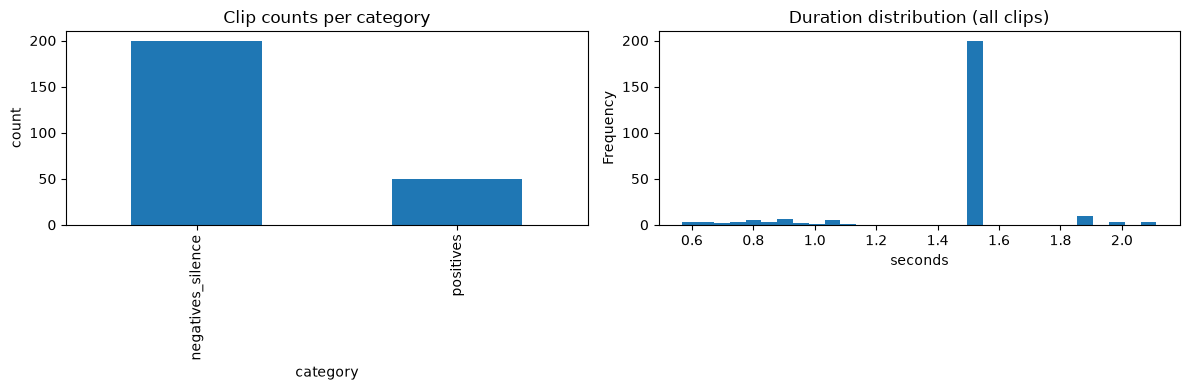

category=negatives_silence  file=data/negatives_silence/sil_synth_pink_0055_000.wav


category=negatives_silence  file=data/negatives_silence/sil_synth_pink_0199_000.wav


category=positives  file=data/positives/en_US-amy-medium_spd0.85_pit-2.wav


category=positives  file=data/positives/fil-PH-AngeloNeural_spd1.0_pit-2.wav


In [23]:
# 20. Dataset statistics & sanity plots
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

counts_by_category = full_manifest.groupby("category").size()
print("Clip counts per category:")
print(counts_by_category)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts_by_category.plot(kind="bar", ax=axes[0], title="Clip counts per category")
axes[0].set_ylabel("count")

if full_manifest["duration_sec"].notna().any():
    full_manifest["duration_sec"].astype(float).plot(
        kind="hist", bins=30, ax=axes[1], title="Duration distribution (all clips)"
    )
    axes[1].set_xlabel("seconds")
plt.tight_layout()
plt.show()

# Spot-check audio playback for a few random samples per category
try:
    import IPython.display as ipd
    for cat, group in full_manifest.groupby("category"):
        sample = group.dropna(subset=["filepath"]).sample(min(2, len(group))) if len(group) else group
        for _, r in sample.iterrows():
            if Path(r["filepath"]).exists():
                print(f"category={cat}  file={r['filepath']}")
                ipd.display(ipd.Audio(r["filepath"]))
except Exception as e:
    print(f"Playback widgets skipped (non-fatal, e.g. non-interactive backend): {e}")


In [26]:
# 21. Manifest export & versioning (README/JSON summary for reproducibility)
# ---------------------------------------------------------------------------
summary = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "wake_word": CONFIG["wake_word"],
    "sample_rate": CONFIG["sample_rate"],
    "random_seed": CONFIG["random_seed"],
    "counts_by_category": counts_by_category.to_dict(),
    "target_counts": CONFIG["target_counts"],
    "config": CONFIG,
}

summary_path = Path(CONFIG["dirs"]["logs"]) / "phase1_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2, default=str)

readme_path = Path(CONFIG["output_root"]) / "README.md"
with open(readme_path, "w") as f:
    f.write(f"""# Wake Word Dataset — Phase 1 Generation Summary

Generated: {summary['generated_at']}
Wake word: \"{CONFIG['wake_word']}\"
Sample rate: {CONFIG['sample_rate']} Hz
Random seed: {CONFIG['random_seed']}

## Clip counts by category
{counts_by_category.to_string()}

## Target counts
{json.dumps(CONFIG['target_counts'], indent=2)}

## Manifest
See `manifest.csv` in this directory (columns: {', '.join(CONFIG['manifest_columns'])}).

Full config snapshot: `logs/phase1_summary.json`.
This dataset feeds the downstream source-level split + augmentation pipeline. The separate `streaming_eval` directory/manifest is reserved for sliding-window false-accept evaluation and must not be used for training.
""")

print(f"Wrote summary -> {summary_path}")
print(f"Wrote README  -> {readme_path}")
print("\nPhase 1 data generation pipeline complete.")


Wrote summary -> data/logs/phase1_summary.json
Wrote README  -> data/README.md

Phase 1 data generation pipeline complete.


## Manual real-recording intake (later)

When you upload real recordings, add them to the manifest using the same schema.
At minimum, populate:

- `filepath`
- `label`
- `category`
- `speaker_id`
- `recording_id`
- `source_id`

For real continuous recordings, create clips from the original recording while
retaining the original `recording_id` as the source-group key. Do **not** assign
independent random IDs to slices from the same recording. This is what prevents
speaker/recording leakage into validation and test.

Recommended real categories are the same five negative families plus positive
wakeword recordings. Real speech/TV/podcast/environmental audio should eventually
replace or supplement the synthetic proxies in both training and the separate
streaming evaluation set.


### Rerun / manual-recording safety

This notebook is designed to be rerun without accumulating duplicate synthetic files. Before generation, it deletes only files matching the generator-owned synthetic filename patterns, then regenerates the configured targets. Files with other names are preserved.

**Do not put manually recorded audio under a generator-owned filename pattern.** Prefer names such as `real_<speaker>_<session>_<take>.wav`. Manual recordings can coexist in the same category directories and can be added to the manifest later.

The notebook never deletes the entire `data/` tree.